In [1]:
%matplotlib widget

# Piecewise 1D inversion

In [2]:
import numpy as np
import pygimli as pg
import empymod as ep
import matplotlib.pyplot as plt
import sys
sys.path.insert(1, '../src')

from FDEM1D3Lay import FDEM1DModelling_nosort
from showStitched import showStitchedModels
from Plot import Plot2Datas

In [3]:
# load true model

model_true = np.load('models/model_s4_c1_uc.npy')
#model_s4_c1_ur = np.load('models/model_s4_c1_ur.npy')

# load true data

data_true = np.load('data/data_s4_c1_uc_sort.npy')

In [4]:
# number of measurement positions 
npos = len(data_true)

# Setting forward operator 

fop = FDEM1DModelling_nosort(nlay=3)

transThk = pg.trans.TransLogLU(0.1,5)
transSig = pg.trans.TransLogLU(10/1000,500/1000)

fop.region(0).setTransModel(transThk)
fop.region(1).setTransModel(transSig)

# Perform inversion in each position

startModel = np.array([2, 2, 0.1, 0.1, 0.1]) # initial model

model_inv = []
response = []

for pos in range(npos):
    dat = data_true[pos]
    rel_err = np.ones_like(dat)*1e-3 
    inv = pg.Inversion(fop)
    model_inv.append(inv.run(dataVals=dat, errorVals=rel_err, startModel=startModel, verbose=False, lam=1 ))
    response.append(inv.response)

<Axes: >

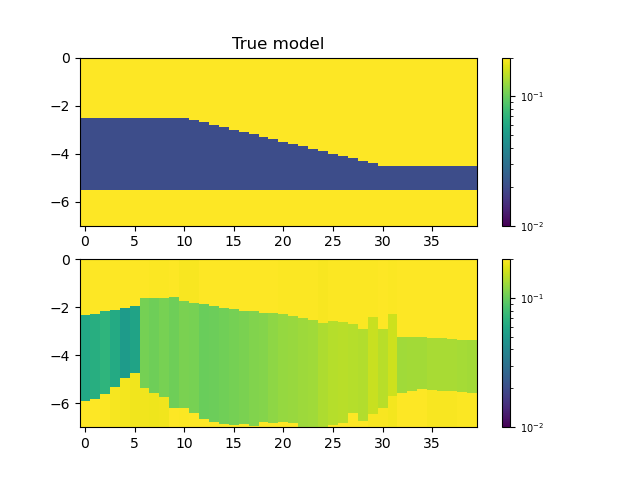

In [5]:
fig, ax = plt.subplots(2,1)

showStitchedModels(model_true, zMax = 7, ax=ax[0], cMin=20/2000, cMax=0.2)
ax[0].set_title('True model')
showStitchedModels(model_inv, zMax = 7, ax=ax[1], cMin=20/2000, cMax=0.2)

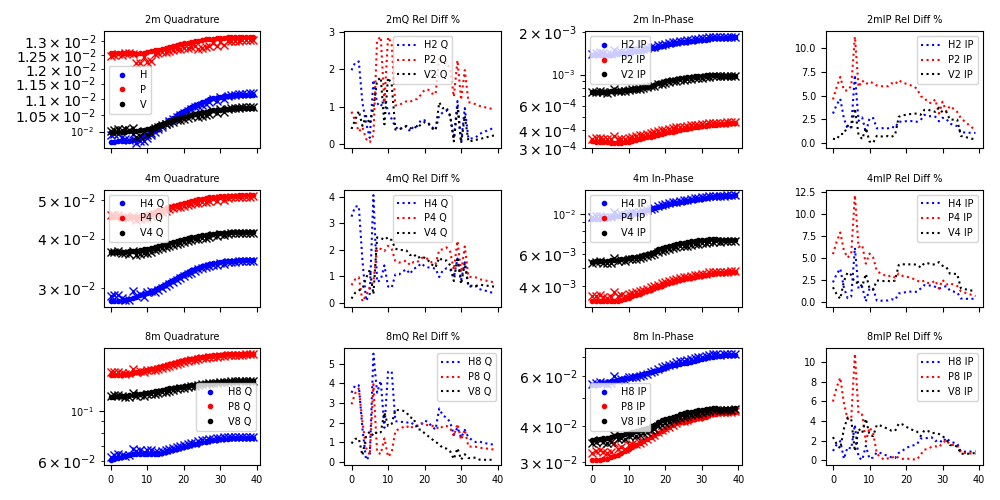

In [6]:
Plot2Datas(data_true, np.array(response).reshape(np.shape(data_true)))